<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Histogram**


Estimated time needed: **45** minutes


In this lab, you will focus on the visualization of data. The dataset will be provided through an RDBMS, and you will need to use SQL queries to extract the required data.


## Objectives


In this lab, you will perform the following:


- Visualize the distribution of data using histograms.

- Visualize relationships between features.

- Explore data composition and comparisons.


## Demo: Working with database


#### Download the database file.


In [1]:
!wget -O survey-data.sqlite https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/QR9YeprUYhOoLafzlLspAw/survey-results-public.sqlite

--2025-07-23 14:07:38--  https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/QR9YeprUYhOoLafzlLspAw/survey-results-public.sqlite
Resolving cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)... 169.63.118.104
Connecting to cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)|169.63.118.104|:443... connected.
200 OKequest sent, awaiting response... 
Length: 211415040 (202M) [application/octet-stream]
Saving to: ‘survey-data.sqlite’

survey-data.sqlite  100%[===================>] 201.62M  55.1MB/s    in 3.7s    

2025-07-23 14:07:42 (54.8 MB/s) - ‘survey-data.sqlite’ saved [211415040/211415040]



#### Install the required libraries and import them


In [2]:
!pip install pandas
!pip install matplotlib
!pip install seaborn
!pip install numpy

import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 163.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 160.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.6/8.6 MB 114.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 121.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 85.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.6/6.6 MB 124.0 MB/s eta 0:00:00


#### Connect to the SQLite database


In [3]:
conn = sqlite3.connect('survey-data.sqlite')

QUERY = "SELECT * FROM main"
df = pd.read_sql_query(QUERY, conn)

# Display the results
print(df)

       ResponseId                      MainBranch                 Age  \
0               1  I am a developer by profession  Under 18 years old   
1               2  I am a developer by profession     35-44 years old   
2               3  I am a developer by profession     45-54 years old   
3               4           I am learning to code     18-24 years old   
4               5  I am a developer by profession     18-24 years old   
...           ...                             ...                 ...   
65432       65433  I am a developer by profession     18-24 years old   
65433       65434  I am a developer by profession     25-34 years old   
65434       65435  I am a developer by profession     25-34 years old   
65435       65436  I am a developer by profession     18-24 years old   
65436       65437     I code primarily as a hobby     18-24 years old   

                Employment                            RemoteWork   Check  \
0      Employed, full-time                     

## Demo: Basic SQL queries

**Demo 1: Count the number of rows in the table**


In [ ]:
QUERY = "SELECT COUNT(*) FROM main"
df = pd.read_sql_query(QUERY, conn)
print(df)


**Demo 2: List all tables**


In [ ]:
QUERY = """
SELECT name as Table_Name 
FROM sqlite_master 
WHERE type = 'table'
"""
pd.read_sql_query(QUERY, conn)


**Demo 3: Group data by age**


In [ ]:
QUERY = """
SELECT Age, COUNT(*) as count 
FROM main 
GROUP BY Age 
ORDER BY Age
"""
df_age = pd.read_sql_query(QUERY, conn)
print(df_age)


## Hands-on Lab: Visualizing Data with Histograms


### 1. Visualizing the distribution of data (Histograms)


**1.1 Histogram of `CompTotal` (Total Compensation)**


Objective: Plot a histogram of `CompTotal` to visualize the distribution of respondents' total compensation.


/tmp/ipykernel_300/3013989799.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered.loc[:, "LogCompTotal"] = np.log1p(df_filtered["CompTotal"])


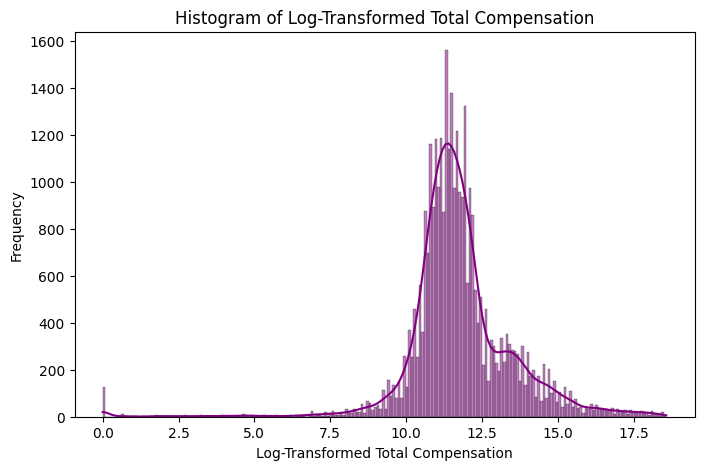

In [5]:
## Write your code here
# Convert to numeric
df["CompTotal"] = pd.to_numeric(df["CompTotal"], errors="coerce")

# Remove extreme outliers (top 1%)
q99 = df["CompTotal"].quantile(0.99)
df_filtered = df[df["CompTotal"] < q99]

# Apply log transformation
df_filtered.loc[:, "LogCompTotal"] = np.log1p(df_filtered["CompTotal"])

# Plot histogram using seaborn
plt.figure(figsize=(8, 5))
sns.histplot(df_filtered["LogCompTotal"], bins='auto', kde=True, color="purple")
plt.xlabel("Log-Transformed Total Compensation")
plt.ylabel("Frequency")
plt.title("Histogram of Log-Transformed Total Compensation")
plt.show()

**1.2 Histogram of YearsCodePro (Years of Professional Coding Experience)**


Objective: Plot a histogram of `YearsCodePro` to analyze the distribution of coding experience among respondents.


In [ ]:
## Write your code here

### 2. Visualizing Relationships in Data


**2.1 Histogram Comparison of `CompTotal` by `Age` Group**


Objective: Use histograms to compare the distribution of CompTotal across different Age groups.


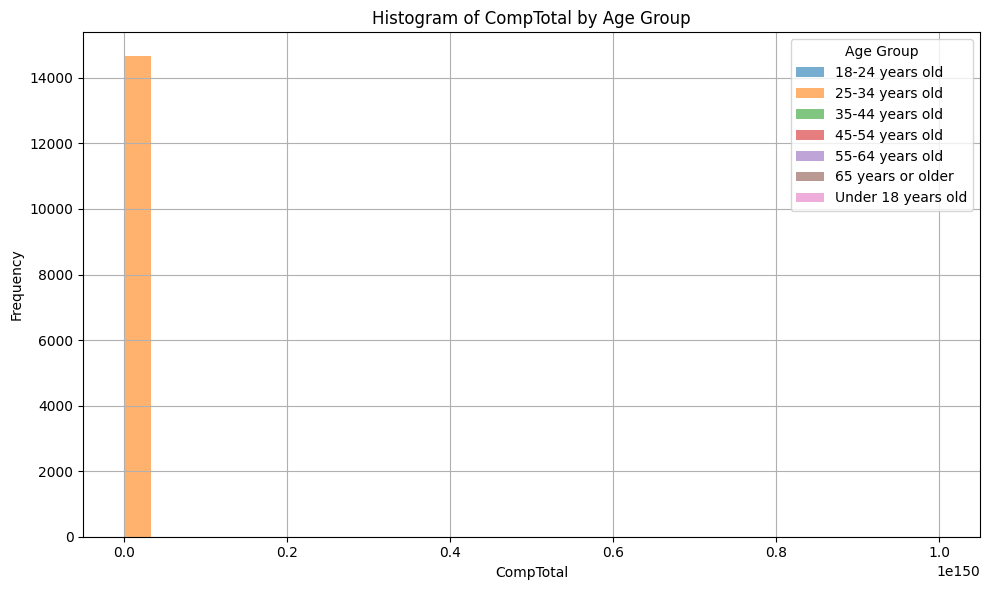

In [30]:
# Drop NaNs for plotting
df_plot = df[['Age', 'CompTotal']].dropna()

# Create histogram for each age group
age_groups = df_plot['Age'].unique()

plt.figure(figsize=(10, 6))
for age in age_groups:
    group_data = df_plot[df_plot['Age'] == age]['CompTotal']
    plt.hist(group_data, bins=30, alpha=0.6, label=str(age))

plt.xlabel('CompTotal')
plt.ylabel('Frequency')
plt.title('Histogram of CompTotal by Age Group')
plt.legend(title='Age Group')
plt.grid(True)
plt.tight_layout()
plt.show()

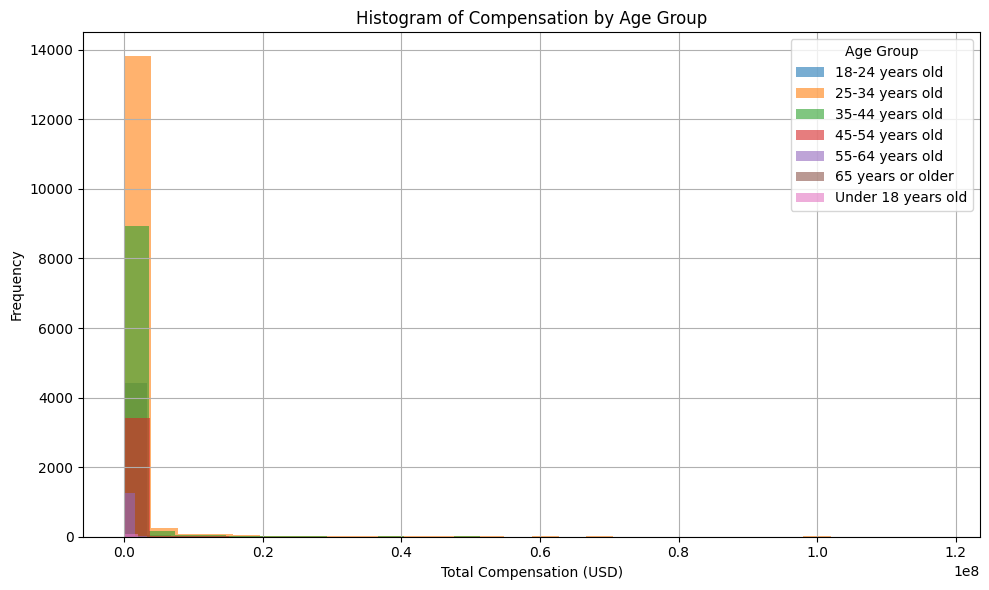

In [26]:
#This is my old code, I tried replacing the plotting code above of yours
#as I dont understand why it only has a single orange column. Just refer to this as 2.1.1

# Ensure age categories are ordered correctly
age_order = [
    "Under 18 years old", "18-24 years old", "25-34 years old", 
    "35-44 years old", "45-54 years old", "55-64 years old", 
    "65 years or older"
]
df["Age"] = pd.Categorical(df["Age"], categories=age_order, ordered=True)

# Ensure CompTotal is numeric and drop missing values
df["CompTotal"] = pd.to_numeric(df["CompTotal"], errors="coerce")
df_plot = df[["Age", "CompTotal"]].dropna()

# Optional: remove top 1% outliers
q99 = df_plot["CompTotal"].quantile(0.99)
df_plot = df_plot[df_plot["CompTotal"] < q99]

# Plot
plt.figure(figsize=(10, 6))
age_groups = df_plot["Age"].dropna().unique()

for age in age_groups:
    group_data = df_plot[df_plot["Age"] == age]["CompTotal"]
    plt.hist(group_data, bins=30, alpha=0.6, label=str(age))

plt.xlabel("Total Compensation (USD)")
plt.ylabel("Frequency")
plt.title("Histogram of Compensation by Age Group")
plt.legend(title="Age Group")
plt.grid(True)
plt.tight_layout()
plt.show()

**2.2 Histogram of TimeSearching for Different Age Groups**

Objective: Use histograms to explore the distribution of `TimeSearching` (time spent searching for information) for respondents across different age groups.


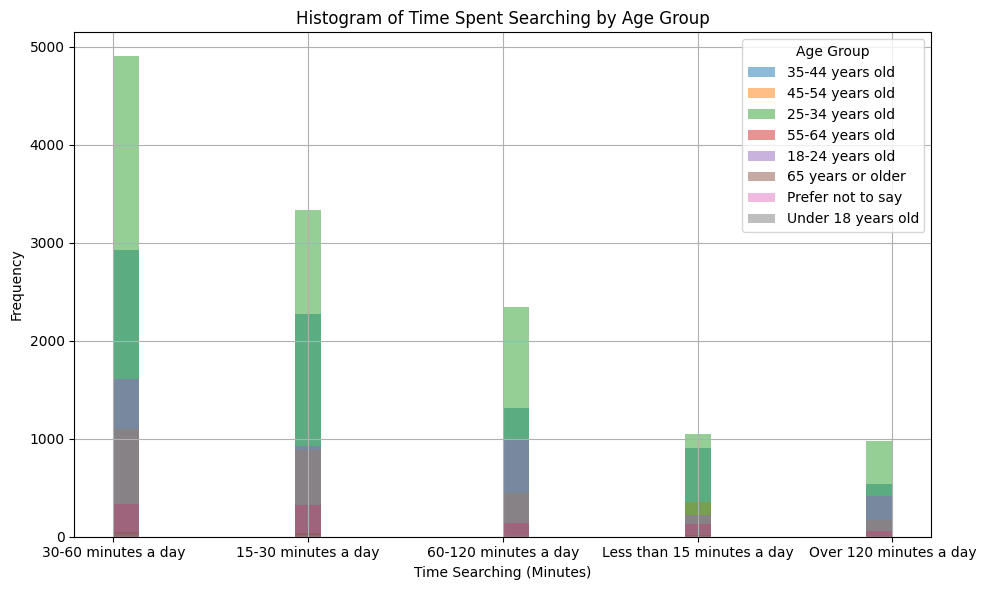

In [12]:
# Drop NaNs for plotting
df_plot = df[['Age', 'TimeSearching']].dropna()

age_groups = df_plot['Age'].unique()

plt.figure(figsize=(10, 6))
for age in age_groups:
    group_data = df_plot[df_plot['Age'] == age]['TimeSearching']
    plt.hist(group_data, bins=30, alpha=0.5, label=str(age))

plt.xlabel('Time Searching (Minutes)')
plt.ylabel('Frequency')
plt.title('Histogram of Time Spent Searching by Age Group')
plt.legend(title='Age Group')
plt.grid(True)
plt.tight_layout()
plt.show()

### 3. Visualizing the Composition of Data


**3.1 Histogram of Most Desired Databases (`DatabaseWantToWorkWith`)**


Objective: Visualize the most desired databases for future learning using a histogram of the top 5 databases.


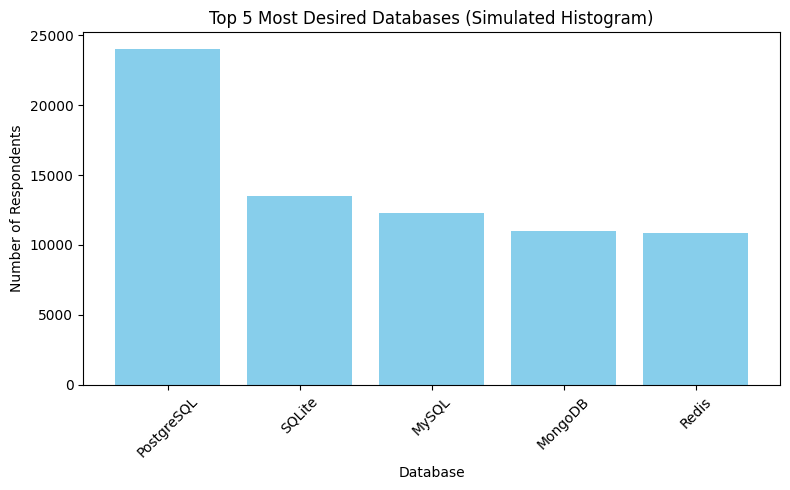

In [13]:
## Write your code 

# Step 1: Split multi-selection into list
df_db = df.copy()
df_db['DatabaseWantToWorkWith'] = df_db['DatabaseWantToWorkWith'].dropna().str.split(';')

# Step 2: Explode to multiple rows
df_db = df_db.explode('DatabaseWantToWorkWith')

# Step 3: Get top 5 databases
top_5 = df_db['DatabaseWantToWorkWith'].value_counts().nlargest(5)

plt.figure(figsize=(8, 5))
plt.bar(top_5.index, top_5.values, color='skyblue')  # use bar instead of hist for clean labeling
plt.title('Top 5 Most Desired Databases (Simulated Histogram)')
plt.xlabel('Database')
plt.ylabel('Number of Respondents')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


**3.2 Histogram of Preferred Work Locations (`RemoteWork`)**


Objective: Use a histogram to explore the distribution of preferred work arrangements (`remote work`).


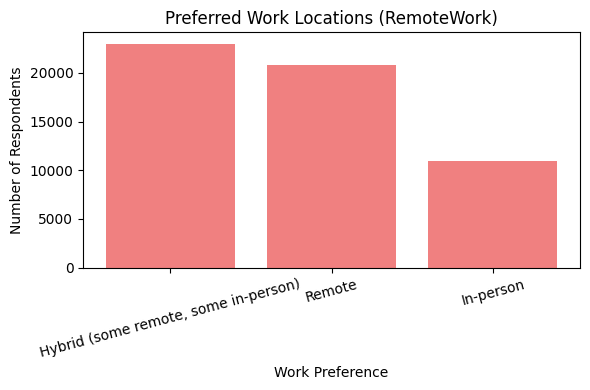

In [14]:
## Write your code here
# Simple frequency count for RemoteWork
remote_counts = df['RemoteWork'].value_counts()

# Plot
plt.figure(figsize=(6, 4))
plt.bar(remote_counts.index, remote_counts.values, color='lightcoral')
plt.title('Preferred Work Locations (RemoteWork)')
plt.xlabel('Work Preference')
plt.ylabel('Number of Respondents')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

### 4. Visualizing Comparison of Data


**4.1 Histogram of Median CompTotal for Ages 45 to 60**


Objective: Plot the histogram for `CompTotal` within the age group 45 to 60 to analyze compensation distribution among mid-career respondents.


In [14]:
df['Age'].value_counts()

Age
25-34 years old       23911
35-44 years old       14942
18-24 years old       14098
45-54 years old        6249
55-64 years old        2575
Under 18 years old     2568
65 years or older       772
Prefer not to say       322
Name: count, dtype: int64

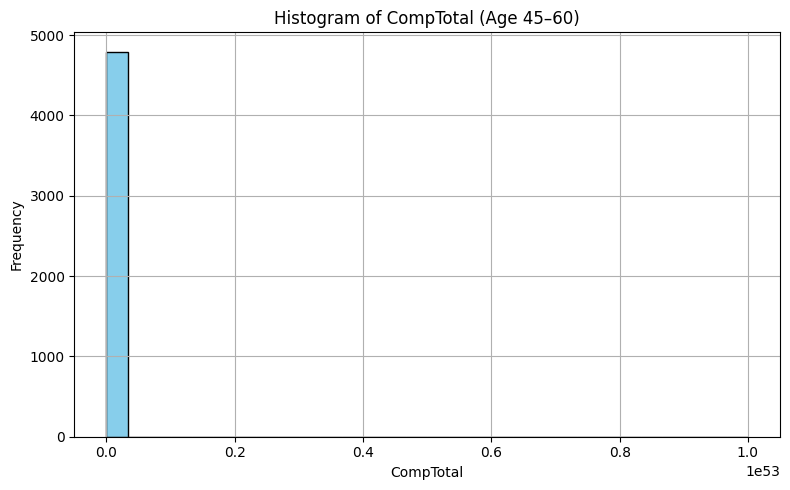

In [33]:
age_mapping = {
    'Under 18 years old': 15,
    '18-24 years old': 21,
    '25-34 years old': 29.5,
    '35-44 years old': 39.5,
    '45-54 years old': 49.5,
    '55-64 years old': 59.5,
    '65 years or older': 70,
    'Prefer not to say': None
}
df['Age_Numeric'] = pd.to_numeric(df['Age'].map(age_mapping))

# Filter data between ages 45 and 60
df_filtered = df[(df['Age_Numeric'] >= 45) & (df['Age_Numeric'] <= 60)]

# Drop NaNs in CompTotal
df_filtered = df_filtered[['CompTotal']].dropna()

plt.figure(figsize=(8, 5))
plt.hist(df_filtered['CompTotal'], bins=30, color='skyblue', edgecolor='black')
plt.xlabel('CompTotal')
plt.ylabel('Frequency')
plt.title('Histogram of CompTotal (Age 45–60)')
plt.grid(True)
plt.tight_layout()
plt.show()

**4.2 Histogram of Job Satisfaction (`JobSat`) by YearsCodePro**


Objective: Plot the histogram for `JobSat` scores based on respondents' years of professional coding experience.


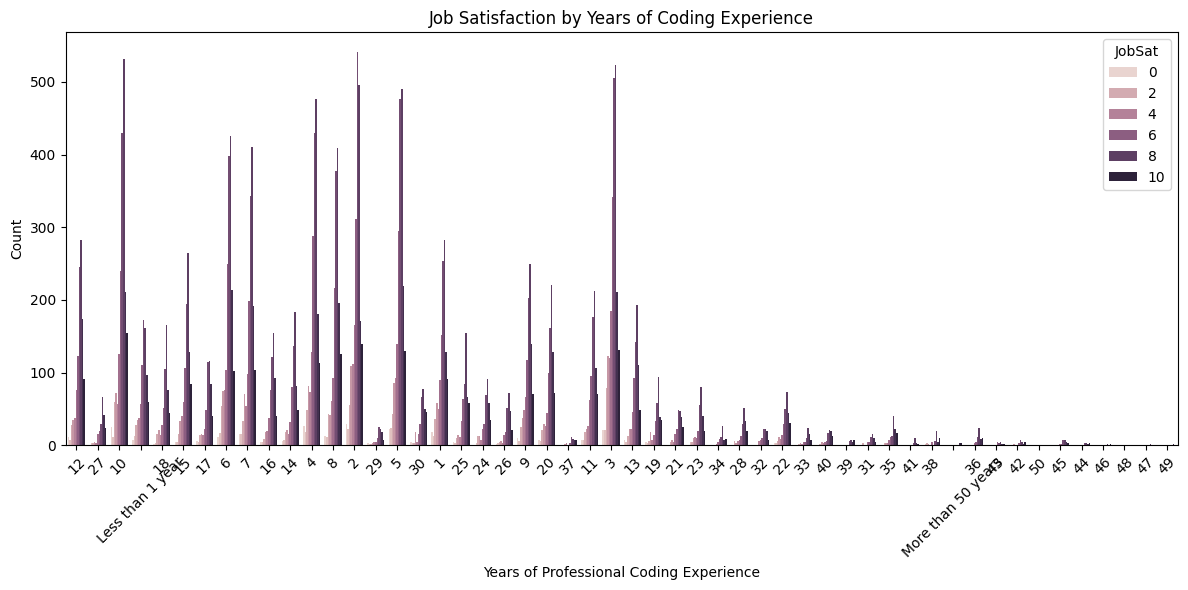

In [21]:
# Drop NaNs and convert types if needed
df_plot = df[['YearsCodePro', 'JobSat']].dropna()
df_plot['YearsCodePro'] = df_plot['YearsCodePro'].astype(str)

plt.figure(figsize=(12, 6))
sns.countplot(data=df_plot, x='YearsCodePro', hue='JobSat')
plt.xlabel('Years of Professional Coding Experience')
plt.ylabel('Count')
plt.title('Job Satisfaction by Years of Coding Experience')
plt.legend(title='JobSat')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Final step: Close the database connection


Once you've completed the lab, make sure to close the connection to the SQLite database:



In [4]:
conn.close()

### Summary


In this lab, you used histograms to visualize various aspects of the dataset, focusing on:

- Distribution of compensation, coding experience, and work hours.

- Relationships in compensation across age groups and work status.

- Composition of data by desired databases and work environments.

- Comparisons of job satisfaction across years of experience.

Histograms helped reveal patterns and distributions in the data, enhancing your understanding of developer demographics and preferences.


## Authors:
Ayushi Jain


### Other Contributors:
- Rav Ahuja
- Lakshmi Holla
- Malika


Copyright © IBM Corporation. All rights reserved.
